In [7]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from src.data_Splitting import divideDataFrame
from src.models import NeuralNetwork
from src.metrics import cross_entropy_loss, accuracy

from src.pytorch_Model import PytorchModel


In [9]:
x_images= np.load('DATA/X_images.npy')
y_images= np.load('DATA/Y_images.npy')

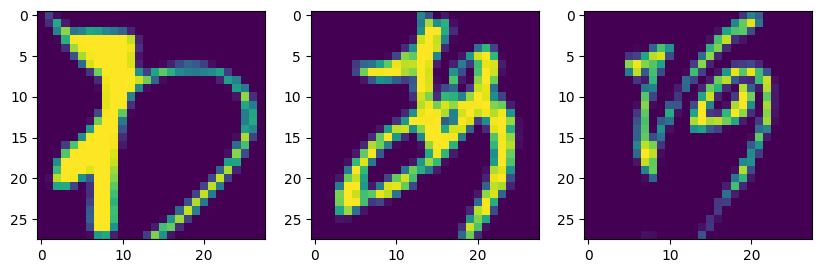

In [28]:
fig,ax= plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(x_images[0].reshape(28,28))
ax[1].imshow(x_images[1].reshape(28,28))
ax[2].imshow(x_images[2].reshape(28,28))


In [26]:
X_images = x_images / 255.0


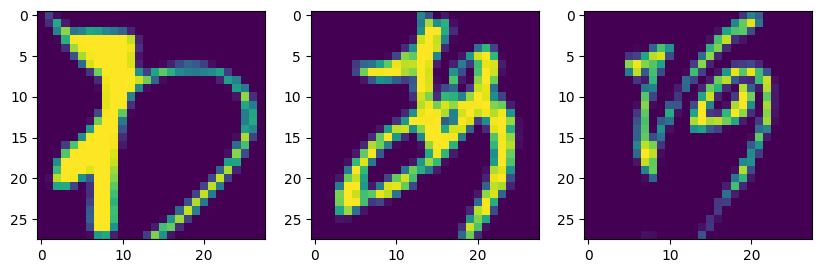

In [32]:
fig,ax= plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(X_images[0].reshape(28,28))
ax[1].imshow(X_images[1].reshape(28,28))
ax[2].imshow(X_images[2].reshape(28,28))

In [12]:
df = pd.DataFrame(X_images)
df['label'] = y_images




In [13]:
df.head()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.207843,0.031373,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.776471,0.129412,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.360784,0.682353,0.035294,0.0,0.0,0.0,0.0,0.0,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 785 entries, 0 to label
dtypes: float32(784), int64(1)
memory usage: 15.0 MB


<Axes: xlabel='label'>

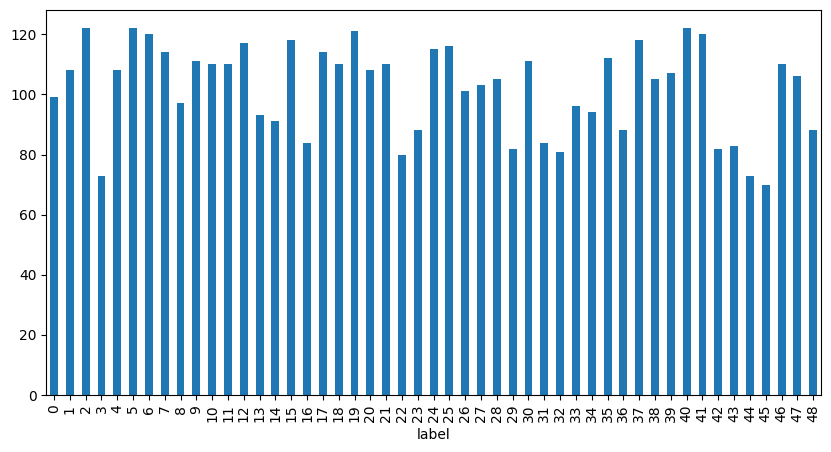

In [33]:
df['label'].value_counts(sort=False).plot(kind='bar', figsize=(10, 5))

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 785 entries, 0 to label
dtypes: float32(784), int64(1)
memory usage: 15.0 MB


In [17]:
df_train, df_temp = divideDataFrame(df, 0.6)  #60%
df_val, df_test = divideDataFrame(df_temp, 0.5) # 20% val y test

In [18]:
print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

Train: (3000, 785), Val: (1000, 785), Test: (1000, 785)


In [19]:
x_train= df_train.drop(columns=['label']).values
y_train= df_train['label'].values

x_val= df_val.drop(columns=['label']).values
y_val= df_val['label'].values

Epoch 0: Train Loss=4.0652, Val Loss=4.0379, Val Acc=0.0230, LR=0.050000
Epoch 10: Train Loss=3.8806, Val Loss=3.9046, Val Acc=0.0310, LR=0.050000
Epoch 20: Train Loss=3.7972, Val Loss=3.8406, Val Acc=0.0460, LR=0.050000
Epoch 30: Train Loss=3.7281, Val Loss=3.7864, Val Acc=0.0640, LR=0.050000
Epoch 40: Train Loss=3.6571, Val Loss=3.7304, Val Acc=0.0800, LR=0.050000
Epoch 50: Train Loss=3.5807, Val Loss=3.6697, Val Acc=0.0970, LR=0.050000
Epoch 60: Train Loss=3.4981, Val Loss=3.6015, Val Acc=0.1170, LR=0.050000
Epoch 70: Train Loss=3.4087, Val Loss=3.5244, Val Acc=0.1340, LR=0.050000
Epoch 80: Train Loss=3.3116, Val Loss=3.4396, Val Acc=0.1710, LR=0.050000
Epoch 90: Train Loss=3.2088, Val Loss=3.3481, Val Acc=0.1930, LR=0.050000
Epoch 100: Train Loss=3.1003, Val Loss=3.2519, Val Acc=0.2160, LR=0.050000
Epoch 110: Train Loss=2.9867, Val Loss=3.1529, Val Acc=0.2480, LR=0.050000
Epoch 120: Train Loss=2.8721, Val Loss=3.0544, Val Acc=0.2760, LR=0.050000
Epoch 130: Train Loss=2.7593, Val Lo

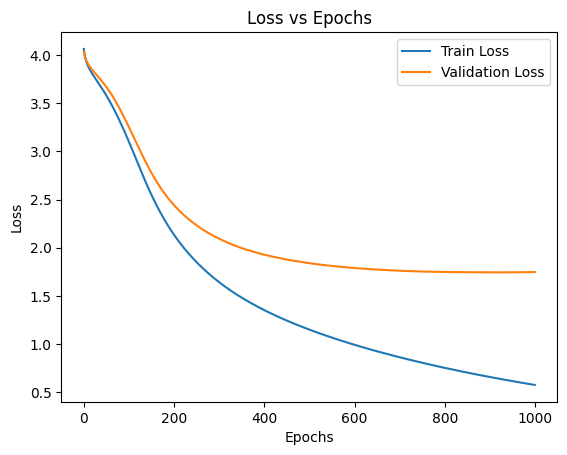

In [ ]:

layers= [784, 100, 80, 49]  
M0 = NeuralNetwork(layers, 
                   lr=0.05,
                   )

M0.fit(x_train, y_train,x_val,y_val, epochs=1000)

M0.metrics()


M0.grafico_loss()

In [15]:
def linear_warmup_saturacion(epoch, warmup_epochs, lr_max):
    """
    Calienta linealmente desde 0 hasta lr_max en warmup_epochs,
    y después mantiene lr_max constante.
    """
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / warmup_epochs
    else:
        return lr_max

def exponential_decay(epoch, initial_lr, decay_rate):
    """
    lr = initial_lr * decay_rate^epoch
    """
    return initial_lr * (decay_rate ** epoch)

Epoch 0: Train Loss=4.0652, Val Loss=4.0678, Val Acc=0.0210, LR=0.010000
Epoch 10: Train Loss=3.8906, Val Loss=3.9040, Val Acc=0.0310, LR=0.110000
Epoch 20: Train Loss=3.6737, Val Loss=3.7264, Val Acc=0.0810, LR=0.210000
Epoch 30: Train Loss=3.2538, Val Loss=3.3420, Val Acc=0.1940, LR=0.310000
Epoch 40: Train Loss=3.6750, Val Loss=3.4675, Val Acc=0.1730, LR=0.410000
Epoch 50: Train Loss=2.7231, Val Loss=2.7310, Val Acc=0.3310, LR=0.500000
Epoch 60: Train Loss=2.4639, Val Loss=2.4224, Val Acc=0.4240, LR=0.500000
Epoch 70: Train Loss=1.7105, Val Loss=2.1648, Val Acc=0.4880, LR=0.500000
Epoch 80: Train Loss=1.6105, Val Loss=2.0057, Val Acc=0.4950, LR=0.500000
Epoch 90: Train Loss=1.3764, Val Loss=1.9852, Val Acc=0.5000, LR=0.500000
Epoch 100: Train Loss=1.1067, Val Loss=1.8056, Val Acc=0.5380, LR=0.500000
Epoch 110: Train Loss=1.2415, Val Loss=1.9308, Val Acc=0.5320, LR=0.500000
Epoch 120: Train Loss=0.9142, Val Loss=1.7983, Val Acc=0.5510, LR=0.500000
Epoch 130: Train Loss=0.8798, Val Lo

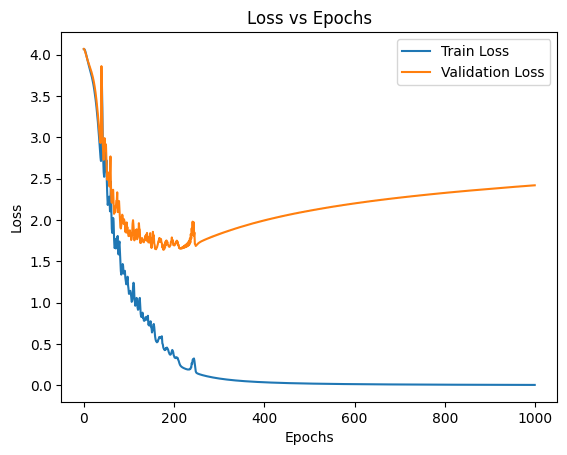

In [16]:
# 4.1 Linear warmup + saturación: sube 5 épocas hasta 0.01, luego fija en 0.01
nn = NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.0,  # ignorado si hay schedule
    lr_schedule=linear_warmup_saturacion,
    schedule_params={"warmup_epochs": 50, "lr_max": 0.5}
)

nn.fit(x_train, y_train, x_val, y_val, epochs=1000)

nn.grafico_loss()


Epoch 0: Train Loss=4.0652, Val Loss=4.0616, Val Acc=0.0200, LR=1.500000
Epoch 10: Train Loss=3.3604, Val Loss=3.4331, Val Acc=0.1240, LR=1.356573
Epoch 20: Train Loss=3.0234, Val Loss=2.8119, Val Acc=0.2840, LR=1.226860
Epoch 30: Train Loss=2.5216, Val Loss=2.6425, Val Acc=0.3580, LR=1.109551
Epoch 40: Train Loss=1.5947, Val Loss=2.1377, Val Acc=0.4430, LR=1.003458
Epoch 50: Train Loss=1.5438, Val Loss=2.0898, Val Acc=0.4770, LR=0.907509
Epoch 60: Train Loss=1.0851, Val Loss=1.8251, Val Acc=0.5280, LR=0.820735
Epoch 70: Train Loss=0.9280, Val Loss=1.7367, Val Acc=0.5490, LR=0.742258
Epoch 80: Train Loss=0.7784, Val Loss=1.6245, Val Acc=0.5850, LR=0.671285
Epoch 90: Train Loss=0.6577, Val Loss=1.6092, Val Acc=0.5920, LR=0.607098
Epoch 100: Train Loss=0.6133, Val Loss=1.5931, Val Acc=0.6000, LR=0.549049
Epoch 110: Train Loss=0.4863, Val Loss=1.5804, Val Acc=0.6080, LR=0.496550
Epoch 120: Train Loss=0.4350, Val Loss=1.5926, Val Acc=0.6080, LR=0.449071
Epoch 130: Train Loss=0.3940, Val Lo

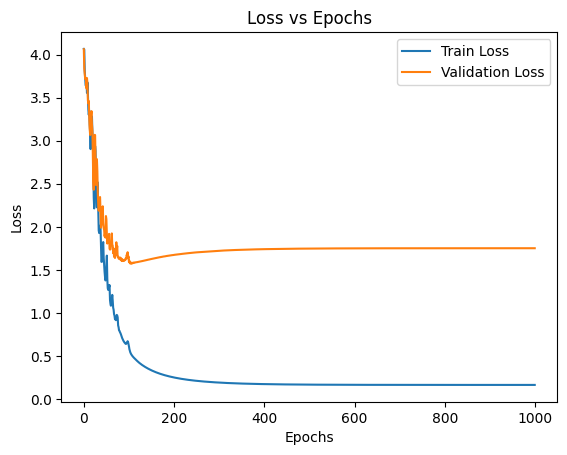

In [17]:

nn = NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.01,
    lr_schedule=exponential_decay,
    schedule_params={"initial_lr": 1.5, "decay_rate": 0.99}
)

# Entrenar
nn.fit(x_train, y_train, x_val, y_val, epochs=1000)

nn.grafico_loss()


Epoch 0: Train Loss=4.0376, Val Loss=4.0185, Val Acc=0.0220, LR=0.001000
Epoch 10: Train Loss=3.8009, Val Loss=3.8428, Val Acc=0.0450, LR=0.001000
Epoch 20: Train Loss=3.6675, Val Loss=3.7376, Val Acc=0.0750, LR=0.001000
Epoch 30: Train Loss=3.5188, Val Loss=3.6174, Val Acc=0.1120, LR=0.001000
Epoch 40: Train Loss=3.3463, Val Loss=3.4683, Val Acc=0.1580, LR=0.001000
Epoch 50: Train Loss=3.1513, Val Loss=3.2943, Val Acc=0.2060, LR=0.001000
Epoch 60: Train Loss=2.9383, Val Loss=3.1081, Val Acc=0.2620, LR=0.001000
Epoch 70: Train Loss=2.7266, Val Loss=2.9259, Val Acc=0.3050, LR=0.001000
Epoch 80: Train Loss=2.5313, Val Loss=2.7592, Val Acc=0.3490, LR=0.001000
Epoch 90: Train Loss=2.3601, Val Loss=2.6157, Val Acc=0.3900, LR=0.001000
Epoch 100: Train Loss=2.2116, Val Loss=2.4973, Val Acc=0.4120, LR=0.001000
Epoch 110: Train Loss=2.0835, Val Loss=2.3991, Val Acc=0.4260, LR=0.001000
Epoch 120: Train Loss=1.9724, Val Loss=2.3167, Val Acc=0.4430, LR=0.001000
Epoch 130: Train Loss=1.8747, Val Lo

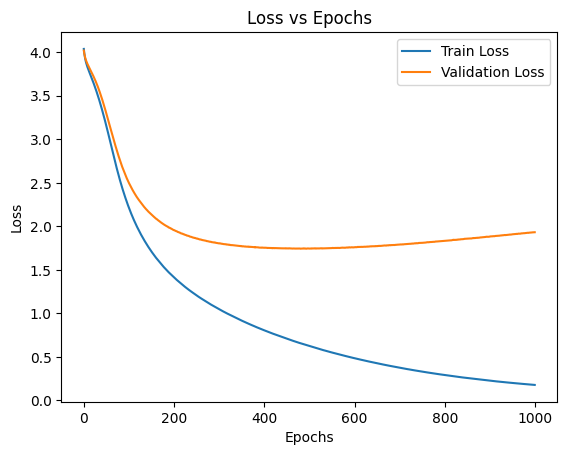

In [18]:
nn= NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.001,
    size_batch=32,
)

nn.fit(x_train, y_train, x_val, y_val, epochs=1000)
nn.grafico_loss()


Epoch 0: Train Loss=4.0652, Val Loss=4.0542, Val Acc=0.0210, LR=0.000100
Epoch 10: Train Loss=3.9340, Val Loss=3.9493, Val Acc=0.0300, LR=0.000100
Epoch 20: Train Loss=3.8469, Val Loss=3.8814, Val Acc=0.0390, LR=0.000100
Epoch 30: Train Loss=3.7777, Val Loss=3.8266, Val Acc=0.0550, LR=0.000100
Epoch 40: Train Loss=3.7120, Val Loss=3.7747, Val Acc=0.0710, LR=0.000100
Epoch 50: Train Loss=3.6429, Val Loss=3.7200, Val Acc=0.0780, LR=0.000100
Epoch 60: Train Loss=3.5673, Val Loss=3.6575, Val Acc=0.0970, LR=0.000100
Epoch 70: Train Loss=3.4831, Val Loss=3.5871, Val Acc=0.1150, LR=0.000100
Epoch 80: Train Loss=3.3907, Val Loss=3.5082, Val Acc=0.1480, LR=0.000100
Epoch 90: Train Loss=3.2899, Val Loss=3.4202, Val Acc=0.1810, LR=0.000100
Epoch 100: Train Loss=3.1807, Val Loss=3.3251, Val Acc=0.2180, LR=0.000100
Epoch 110: Train Loss=3.0648, Val Loss=3.2254, Val Acc=0.2550, LR=0.000100
Epoch 120: Train Loss=2.9452, Val Loss=3.1218, Val Acc=0.2880, LR=0.000100
Epoch 130: Train Loss=2.8238, Val Lo

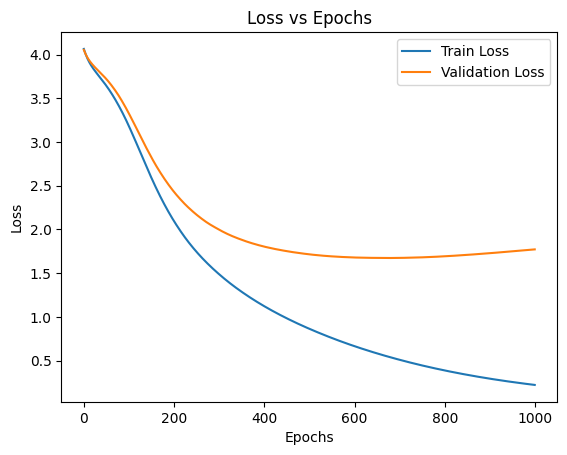

In [19]:
nn= NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.0001,
    optimizer='adam'
)

nn.fit(x_train, y_train, x_val, y_val, epochs=1000)
nn.grafico_loss()


Epoch 0: Train Loss=4.0660, Val Loss=4.0402, Val Acc=0.0230, LR=0.050000
Epoch 10: Train Loss=3.8814, Val Loss=3.9069, Val Acc=0.0310, LR=0.050000
Epoch 20: Train Loss=3.7980, Val Loss=3.8429, Val Acc=0.0460, LR=0.050000
Epoch 30: Train Loss=3.7288, Val Loss=3.7887, Val Acc=0.0640, LR=0.050000
Epoch 40: Train Loss=3.6578, Val Loss=3.7327, Val Acc=0.0800, LR=0.050000
Epoch 50: Train Loss=3.5814, Val Loss=3.6720, Val Acc=0.0970, LR=0.050000
Epoch 60: Train Loss=3.4988, Val Loss=3.6038, Val Acc=0.1170, LR=0.050000
Epoch 70: Train Loss=3.4094, Val Loss=3.5266, Val Acc=0.1340, LR=0.050000
Epoch 80: Train Loss=3.3123, Val Loss=3.4420, Val Acc=0.1700, LR=0.050000
Epoch 90: Train Loss=3.2096, Val Loss=3.3504, Val Acc=0.1930, LR=0.050000
Epoch 100: Train Loss=3.1010, Val Loss=3.2543, Val Acc=0.2160, LR=0.050000
Epoch 110: Train Loss=2.9874, Val Loss=3.1552, Val Acc=0.2480, LR=0.050000
Epoch 120: Train Loss=2.8729, Val Loss=3.0567, Val Acc=0.2750, LR=0.050000
Epoch 130: Train Loss=2.7601, Val Lo

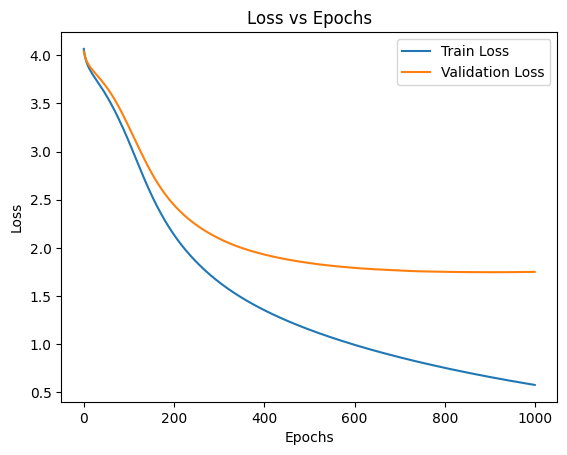

In [20]:
nn= NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.05,
    L2_lambda=0.01,
)

nn.fit(x_train, y_train, x_val, y_val, epochs=1000)
nn.grafico_loss()

Epoch 0: Train Loss=4.1246, Val Loss=4.0794, Val Acc=0.0200, LR=0.050000
Epoch 10: Train Loss=3.9189, Val Loss=3.9283, Val Acc=0.0330, LR=0.050000
Epoch 20: Train Loss=3.8439, Val Loss=3.8810, Val Acc=0.0300, LR=0.050000
Epoch 30: Train Loss=3.7886, Val Loss=3.8327, Val Acc=0.0470, LR=0.050000
Epoch 40: Train Loss=3.7467, Val Loss=3.7824, Val Acc=0.0710, LR=0.050000
Epoch 50: Train Loss=3.6977, Val Loss=3.7678, Val Acc=0.0680, LR=0.050000
Epoch 60: Train Loss=3.6410, Val Loss=3.7344, Val Acc=0.0730, LR=0.050000
Epoch 70: Train Loss=3.5857, Val Loss=3.6675, Val Acc=0.0850, LR=0.050000
Epoch 80: Train Loss=3.5303, Val Loss=3.6214, Val Acc=0.1000, LR=0.050000
Epoch 90: Train Loss=3.4707, Val Loss=3.5978, Val Acc=0.1170, LR=0.050000
Epoch 100: Train Loss=3.4123, Val Loss=3.5201, Val Acc=0.1360, LR=0.050000
Epoch 110: Train Loss=3.3608, Val Loss=3.4465, Val Acc=0.1500, LR=0.050000
Epoch 120: Train Loss=3.2889, Val Loss=3.3990, Val Acc=0.1620, LR=0.050000
Epoch 130: Train Loss=3.2121, Val Lo

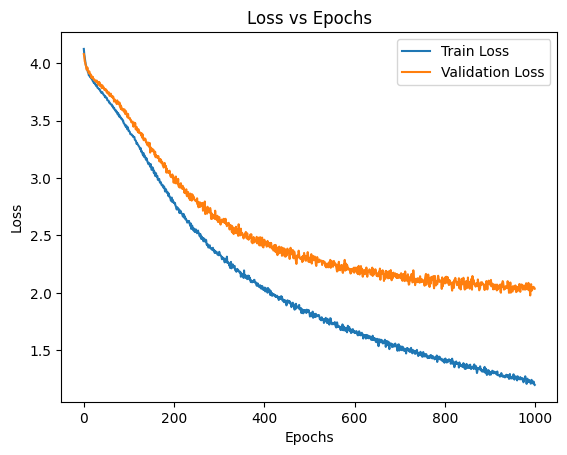

In [21]:
nn= NeuralNetwork(
    layer_sizes=[784,100,80,49],
    lr=0.05,
    dropout_prob=0.15,
)

nn.fit(x_train, y_train, x_val, y_val, epochs=1000)
nn.grafico_loss()

In [40]:
layers= [[784,1024,512,49],[784, 512, 256, 49],[784, 256, 128, 49]]
lrs=[0.01, 0.001]
optimizers=['adam', 'sgd']
dropout_probs=[None, 0.5]
L2_lambdas=[None, 0.01]
batch_sizes=[None,32, 64]


mejor_val_loss = np.inf
mejor_params = None
resultados = []
count=0
for layer_sizes in layers:
    for lr in lrs:
        for optimizer in optimizers:
            for dropout_prob in dropout_probs:
                for L2_lambda in L2_lambdas:
                    for batch_size in batch_sizes:
                        count+=1 
                        print(f"Configuración {count}")                    
                        nn = NeuralNetwork(
                            layer_sizes=layer_sizes,
                            lr=lr,
                            optimizer=optimizer,
                            dropout_prob=dropout_prob,
                            L2_lambda=L2_lambda,
                            size_batch=batch_size,
                            early_stopping=True,
                            patience=10,
                            Print=False
                        )

                        nn.fit(x_train, y_train, x_val, y_val, epochs=200)

                        val_loss = nn.history['val_loss'][-1]


                        resultados.append({
                            "layer_sizes": layer_sizes,
                            "lr": lr,
                            "optimizer": optimizer,
                            "dropout_prob": dropout_prob,
                            "L2_lambda": L2_lambda,
                            "batch_size": batch_size,
                        })

                        if val_loss < mejor_val_loss:
                            mejor_val_loss = val_loss
                            mejor_params = resultados[-1]
                        


print("\nMejor configuración encontrada:")
print(mejor_params)
print(f"Mejor val_loss: {mejor_val_loss:.4f}")


Configuración 1
Configuración 2
Configuración 3
Configuración 4
Configuración 5
Configuración 6
Configuración 7
Configuración 8
Configuración 9
Configuración 10
Configuración 11
Configuración 12
Configuración 13
Configuración 14
Configuración 15
Configuración 16
Configuración 17
Configuración 18
Configuración 19
Configuración 20
Configuración 21
Configuración 22
Configuración 23
Configuración 24
Configuración 25
Configuración 26
Configuración 27
Configuración 28
Configuración 29
Configuración 30
Configuración 31
Configuración 32
Configuración 33
Configuración 34
Configuración 35
Configuración 36
Configuración 37
Configuración 38
Configuración 39
Configuración 40
Configuración 41
Configuración 42
Configuración 43
Configuración 44
Configuración 45
Configuración 46
Configuración 47
Configuración 48
Configuración 49
Configuración 50
Configuración 51
Configuración 52
Configuración 53
Configuración 54
Configuración 55
Configuración 56
Configuración 57
Configuración 58
Configuración 59
Config

Epoch 0: Train Loss=2.5046, Val Loss=1.8414, Val Acc=0.5440, LR=0.001000
Epoch 10: Train Loss=0.0049, Val Loss=1.6068, Val Acc=0.6890, LR=0.001000
Train Loss: 0.15136368672951286
Validation Loss: 1.419946856935977
Validation Accuracy: 0.677


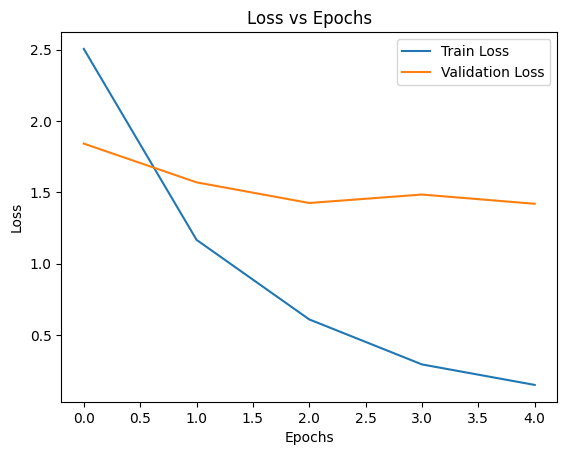

In [42]:
M1=NeuralNetwork(
    layer_sizes=[784, 1024, 512, 49],
    lr=0.001,
    optimizer='adam',
    early_stopping=True,
    patience=10,
    size_batch=32,
    )
M1.fit(x_train, y_train, x_val, y_val, epochs=200)

M1.metrics()
M1.grafico_loss()

EPOCH:10, Train: 0.0159 | Val: 1.7374
Early stopping at epoch 14
Train Loss: 0.0058317396999089085
Validation Loss: 1.8547879699617624
Validation Accuracy: 0.683


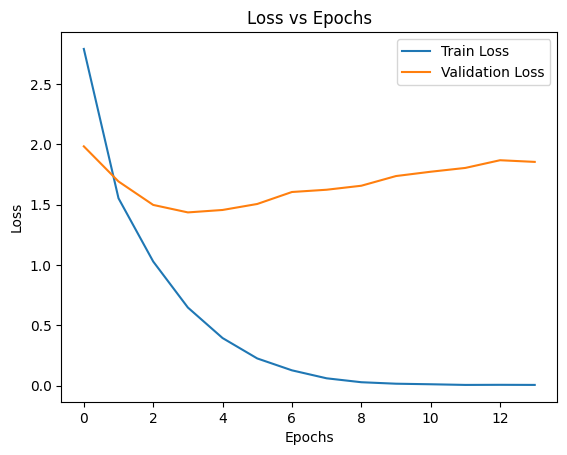

In [45]:
M2=PytorchModel(
    layer_sizes=[784, 1024, 512, 49],
    lr=0.001,
    optimizer='adam',
    early_stopping=True,
    patience=10,
    size_batch=32,
    )
M2.fit(x_train, y_train, x_val, y_val, max_epochs=200)

M2.metrics()
M2.grafico_loss()

In [39]:
layers= [[784,1024,512,49],[784, 512, 256, 49],[784, 256, 128, 49]]
lrs=[0.01, 0.001]
optimizers=['adam', 'sgd']
dropout_probs=[None, 0.5]
L2_lambdas=[None, 0.01]
batch_sizes=[None,32, 64]


mejor_val_loss = np.inf
mejor_params = None
resultados = []
count=0

for layer_sizes in layers:
    for lr in lrs:
        for optimizer in optimizers:
            for dropout_prob in dropout_probs:
                for L2_lambda in L2_lambdas:
                    for batch_size in batch_sizes:
                        count+=1 
                        print(f"Configuración {count}")                    
                        nn = PytorchModel(
                            layer_sizes=layer_sizes,
                            lr=lr,
                            optimizer=optimizer,
                            dropout_prob=dropout_prob,
                            L2_lambda=L2_lambda,
                            size_batch=batch_size,
                            early_stopping=True,
                            patience=10,
                        )

                        nn.fit(x_train, y_train, x_val, y_val, max_epochs=200)

                        val_loss = nn.historia['val_loss'][-1]


                        resultados.append({
                            "layer_sizes": layer_sizes,
                            "lr": lr,
                            "optimizer": optimizer,
                            "dropout_prob": dropout_prob,
                            "L2_lambda": L2_lambda,
                            "batch_size": batch_size,
                        })

                        if val_loss < mejor_val_loss:
                            mejor_val_loss = val_loss
                            mejor_params = resultados[-1]

print("\nMejor configuración encontrada:")
print(mejor_params)
print(f"Mejor val_loss: {mejor_val_loss:.4f}")


Configuración 1
EPOCH:10, Train: 0.3524 | Val: 2.8408
Early stopping at epoch 13
Configuración 2
EPOCH:10, Train: 0.6762 | Val: 3.0250
Early stopping at epoch 13
Configuración 3
EPOCH:10, Train: 0.3524 | Val: 2.8408
Early stopping at epoch 13
Configuración 4
EPOCH:10, Train: 1.4521 | Val: 1.8429
EPOCH:20, Train: 1.2616 | Val: 1.7153
EPOCH:30, Train: 1.1795 | Val: 1.6767
Early stopping at epoch 38
Configuración 5
EPOCH:10, Train: 1.7313 | Val: 2.0245
EPOCH:20, Train: 1.5428 | Val: 1.8811
EPOCH:30, Train: 1.5025 | Val: 1.8063
EPOCH:40, Train: 1.4546 | Val: 1.8327
EPOCH:50, Train: 1.3993 | Val: 1.8158
Early stopping at epoch 54
Configuración 6
EPOCH:10, Train: 1.4521 | Val: 1.8429
EPOCH:20, Train: 1.2616 | Val: 1.7153
EPOCH:30, Train: 1.1795 | Val: 1.6767
Early stopping at epoch 38
Configuración 7
EPOCH:10, Train: 2.8880 | Val: 2.4503
Early stopping at epoch 13
Configuración 8
EPOCH:10, Train: 3.3774 | Val: 3.1028
Early stopping at epoch 11
Configuración 9
EPOCH:10, Train: 2.8880 | Val: 2

EPOCH:10, Train: 1.8594 | Val: 1.8354
EPOCH:20, Train: 1.0951 | Val: 1.4912
EPOCH:30, Train: 0.6360 | Val: 1.4253
Early stopping at epoch 39
Train Loss: 0.40036656881900545
Validation Loss: 1.4237599298357964
Validation Accuracy: 0.659


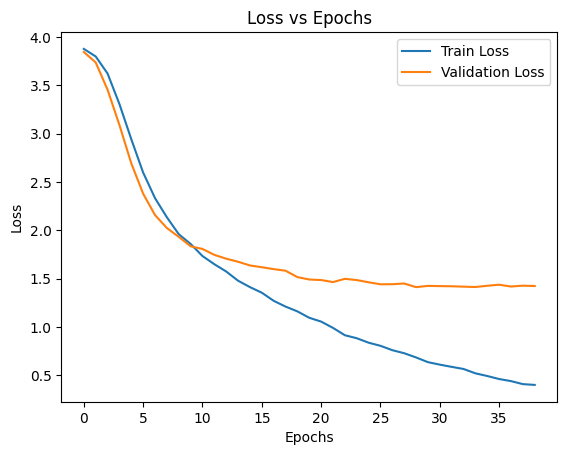

In [ ]:
M3=PytorchModel(
    layer_sizes=[784, 512, 256, 49],
    lr=0.01,
    optimizer='sgd',
    early_stopping=True,
    patience=10,
    dropout_prob=0.5,
)
M3.fit(x_train, y_train, x_val, y_val, max_epochs=200)

M3.metrics()
M3.grafico_loss()


EPOCH:10, Train: 3.8791 | Val: 3.8827
EPOCH:20, Train: 3.8585 | Val: 3.8661
EPOCH:30, Train: 3.8125 | Val: 3.8258
EPOCH:40, Train: 3.6536 | Val: 3.6735
EPOCH:50, Train: 3.2983 | Val: 3.3286
EPOCH:60, Train: 2.8294 | Val: 2.8983
EPOCH:70, Train: 2.3490 | Val: 2.4738
EPOCH:80, Train: 2.0253 | Val: 2.1875
EPOCH:90, Train: 1.7973 | Val: 2.0311
EPOCH:100, Train: 1.6170 | Val: 1.9482
EPOCH:110, Train: 1.4688 | Val: 1.8805
EPOCH:120, Train: 1.3342 | Val: 1.8415
EPOCH:130, Train: 1.2111 | Val: 1.8069
EPOCH:140, Train: 1.1071 | Val: 1.8116
EPOCH:150, Train: 1.0004 | Val: 1.7935
EPOCH:160, Train: 0.9004 | Val: 1.7942
EPOCH:170, Train: 0.8199 | Val: 1.7734
EPOCH:180, Train: 0.7234 | Val: 1.7870
EPOCH:190, Train: 0.6349 | Val: 1.8222
EPOCH:200, Train: 0.5520 | Val: 1.8393
EPOCH:210, Train: 0.4665 | Val: 1.8672
EPOCH:220, Train: 0.3958 | Val: 1.9072
EPOCH:230, Train: 0.3255 | Val: 1.9612
EPOCH:240, Train: 0.2661 | Val: 2.0086
EPOCH:250, Train: 0.2158 | Val: 2.0613
EPOCH:260, Train: 0.1737 | Val: 2.

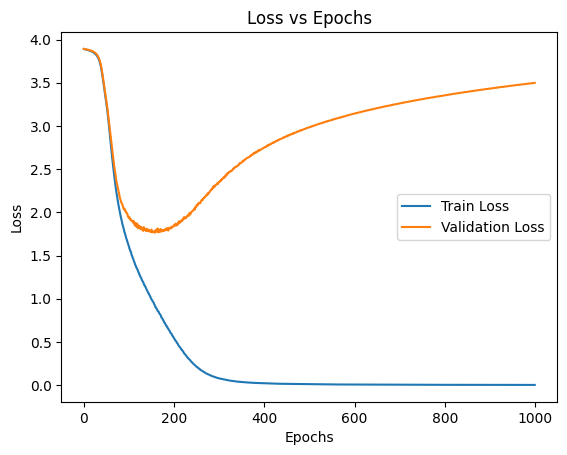

In [47]:
M4= PytorchModel(
    layer_sizes=[784,1024, 512, 256, 49],
    lr=0.001,
    optimizer='sgd',
)

M4.fit(x_train, y_train, x_val, y_val, max_epochs=1000)

M4.metrics()
M4.grafico_loss()

In [48]:
x_test= df_test.drop(columns=['label']).values

y_test= df_test['label'].values


m0_pred= M0.predict(x_test)
m1_pred= M1.predict(x_test)
m2_pred= M2.predict(x_test)
m3_pred= M3.predict(x_test)
m4_pred= M4.predict(x_test)

m0_prob= M0.predict_proba(x_test)
m1_prob= M1.predict_proba(x_test)
m2_prob= M2.predict_proba(x_test)
m3_prob= M3.predict_proba(x_test)
m4_prob= M4.predict_proba(x_test)

m0_weights = M0.weights
m1_weights = M1.weights
m2_weights = M2.weigths()
m3_weights = M3.weigths()
m4_weights = M4.weigths()

y_true = y_test

preds = [
    ("M0", m0_pred,m0_prob, m0_weights),
    ("M1", m1_pred,m1_prob, m1_weights),
    ("M2", m2_pred,m2_prob, m2_weights),
    ("M3", m3_pred,m3_prob, m3_weights),
    ("M4", m4_pred,m4_prob, m4_weights)
]
    
for name, y_pred,y_prob,weight in preds:
    print(f"\n=== Métricas para {name} ===")
    acc = accuracy(y_true, y_pred)

    loss=cross_entropy_loss(y_true, y_prob, weight)

    print(f"Accuracy               : {acc:.4f}")
    print(f"Cross Entropy Loss     : {loss:.4f}")



=== Métricas para M0 ===
Accuracy               : 0.5800
Cross Entropy Loss     : 1.7316

=== Métricas para M1 ===
Accuracy               : 0.6650
Cross Entropy Loss     : 1.4187

=== Métricas para M2 ===
Accuracy               : 0.6720
Cross Entropy Loss     : 1.8115

=== Métricas para M3 ===
Accuracy               : 0.6600
Cross Entropy Loss     : 1.3702

=== Métricas para M4 ===
Accuracy               : 0.5790
Cross Entropy Loss     : 3.2812


In [22]:
X_comp = np.load("Data/X_COMP.npy")  # shape (N, 784)
x_comp= X_comp / 255.0

np.info(X_comp)

class:  ndarray
shape:  (1000, 784)
strides:  (3136, 4)
itemsize:  4
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x1580c0000
byteorder:  little
byteswap:  False
type: float32


In [49]:


probs=M3.predict_proba(X_comp)


cols = [f"class_{i}" for i in range(probs.shape[1])]
df_preds = pd.DataFrame(probs, columns=cols)


output_filename = "Szterensus_Joaquin_predicciones.csv"
df_preds.to_csv(output_filename, index=False)

